In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("materials_data.csv")
print(f"Loaded {len(df)} materials")
print(df.head())

Loaded 20194 materials
           id formula  bandgap  formation_energy   density       volume
0    mp-32800   Ac2S3   2.2962         -2.493064  6.535149  1118.407852
1   mp-977351   Ac2S3   3.0275         -2.440364  5.562971   328.464893
2  mp-1183052   AcBO3   0.8071         -2.475390  9.206879    51.548126
3   mp-866101  AcCrO3   2.0031         -3.138972  8.848788    61.362845
4   mp-861502  AcFeO3   0.9888         -2.771539  8.889999    61.797311


In [18]:
print("shape:", df.shape) #tells how many row and coloumns are
print("\nColumns:" , list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print(f"\nUnique materials: {df['formula'].nunique()}")
print(f"Unique bandgaps values: {df['bandgap'].unique()}")

shape: (20194, 6)

Columns: ['id', 'formula', 'bandgap', 'formation_energy', 'density', 'volume']

Data types:
id                   object
formula              object
bandgap             float64
formation_energy    float64
density             float64
volume              float64
dtype: object

Statistics:
            bandgap  formation_energy       density        volume
count  20194.000000      20194.000000  20194.000000  20194.000000
mean       1.748529         -1.719014      4.567107    578.403810
std        0.828653          0.990598      1.825282    670.207188
min        0.500300         -4.389466      0.020144     16.207758
25%        1.031925         -2.411178      3.295815    211.347612
50%        1.647400         -1.764878      4.299517    371.569747
75%        2.379675         -0.996346      5.598817    709.888184
max        3.499800          4.688205     15.230460  20090.906408

Missing values:
id                  0
formula             0
bandgap             0
formation_energy 

In [39]:
wide_bg=df[df['bandgap']>2.0]
print(f"Wide bandgap materials: {len(wide_bg)}")

stable_semi=df[(df['formation_energy']<-1.0) & (df['bandgap']>0.5)]
print(stable_semi.formula)
print(f"Stable semiconductors: {len(stable_semi)}")

print("\nTop 5 most stable")
print(df.nsmallest(5,'formation_energy')[['formula','bandgap','formation_energy']])

print("\nTop 5 highest bandgap:")
print(df.nlargest(5,'bandgap')[['formula','formation_energy', 'bandgap']])

print("\nAverage bandgap by number of elements:")
print(df.groupby('n_elements')['bandgap'].agg(['mean','std','count']))

Wide bandgap materials: 7551
0          Ac2S3
1          Ac2S3
2          AcBO3
3         AcCrO3
4         AcFeO3
          ...   
20188     ZrTiS6
20189    ZrTl2S3
20190     ZrV2O7
20191      ZrVF6
20193     ZrZnN2
Name: formula, Length: 15126, dtype: object
Stable semiconductors: 15126

Top 5 most stable
           formula  bandgap  formation_energy
5356          CeF3   0.9484         -4.389466
5503      CeTh9O20   2.0082         -4.321499
7305   Ca20Er10F69   0.6098         -4.298855
15257       Nd6F17   0.6975         -4.286478
17203      Th5OF19   0.7837         -4.284045

Top 5 highest bandgap:
       formula  formation_energy  bandgap
7838   CaSn2F6         -3.114991   3.4998
279      Al2O3         -3.221614   3.4995
8433     H7NO6         -1.108913   3.4995
18006  Tm3TaO7         -3.862135   3.4992
6842   LiFe2F7         -2.649717   3.4987

Average bandgap by number of elements:
                mean       std  count
n_elements                           
1           1.771217  0.

In [50]:
print(f"Before cleaning: {len(df)} rows")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"duplicates: {df.duplicated().sum()}")
df=df.dropna()# Remove rows containing missing (NaN) values
df=df.drop_duplicates(subset=['formula'])# Remove duplicate materials based on chemical formula
print(f"after cleaning: {len(df)} rows")
print("no missing values:", df.isnull().sum().sum()==0)  # Check if the dataset contains any missing values
# like last sum() do the addition of the previous count and then if the sum is 0 then true otherwise false 


Before cleaning: 12359 rows
Missing values:
id                  0
formula             0
bandgap             0
formation_energy    0
density             0
volume              0
n_elements          0
dtype: int64
duplicates: 0
after cleaning: 12359 rows
no missing values: True


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("materials_data.csv")
print(f"Loaded {len(df)} materials")

Loaded 20194 materials


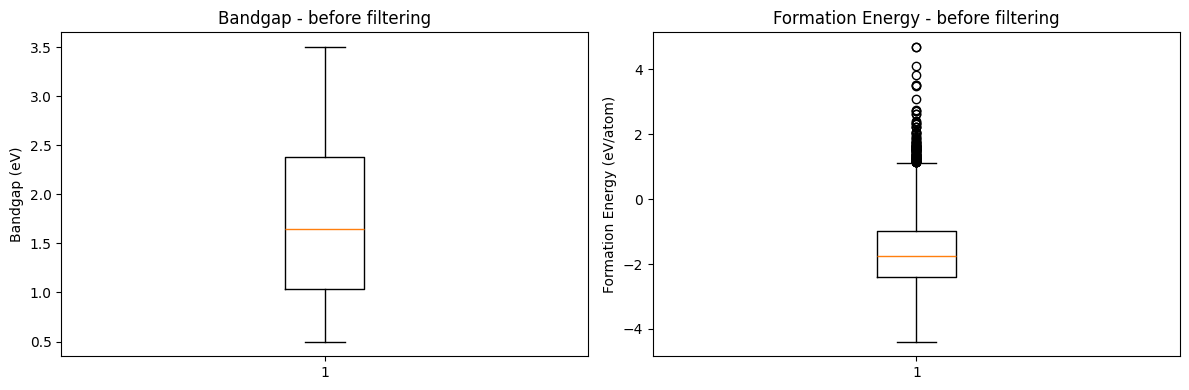

before outlier removal: 20194
after outlier removal: 19888
removed:306 outliers


In [5]:
fig, axes = plt.subplots(1,2,figsize =(12,4))  #1 row and 2 column adn width=12 inch and height =4 inch
axes[0].boxplot(df['bandgap'])
axes[0].set_title('Bandgap - before filtering')
axes[0].set_ylabel('Bandgap (eV)')

axes[1].boxplot(df['formation_energy'])
axes[1].set_title('Formation Energy - before filtering')
axes[1].set_ylabel('Formation Energy (eV/atom)')
plt.tight_layout()
plt.show()
df_clean=df[
    (df['formation_energy']>= -4.0) &
    (df['formation_energy']<=0.5)&
    (df['bandgap']>=0.3)&
    (df['bandgap']<=6.0)&
    (df['density']>0)].copy()
print(f"before outlier removal: {len(df)}")
print (f"after outlier removal: {len(df_clean)}")
print(f"removed:{len(df) - len(df_clean)} outliers")

# Box = middle 50% of the data
# Orange line = median (middle value)
# Whiskers = normal range of values the straight line above and below the box
# Dots outside whiskers = outliers (unusual values) for plot 2
# Outlier does not always mean wrong data they are very far than the range
# Boxplots help identify data spread and outliers before ML



In [17]:
df_clean['energy_per_volume']=df_clean['formation_energy']/df_clean['volume']
df_clean['is_binary']=(df_clean['n_elements']==2).astype(int)
df_clean['is_ternary']=(df_clean['n_elements']==3).astype(int) 
def bg_category(bg):
    if bg<1.0:
        return 'narrow'
    elif bg<2.5:
        return 'medium'
    else:
        return 'wide'
df_clean['bg_category']=df_clean['bandgap'].apply(bg_category)
print("new columns added!")
print(df_clean[['formula','bandgap','bg_category','is_binary','is_ternary']].head(10))
print(f"\nBandgap categories:")
print(df_clean['bg_category'].value_counts())

# Feature engineering:
# Create new useful columns from existing data
# Categorize bandgap as narrow/medium/wide
# Create binary and ternary material indicators
# Count materials in each bandgap category
    

new columns added!
   formula  bandgap bg_category  is_binary  is_ternary
0    Ac2S3   2.2962      medium          1           0
1    Ac2S3   3.0275        wide          1           0
2    AcBO3   0.8071      narrow          0           1
3   AcCrO3   2.0031      medium          0           1
4   AcFeO3   0.9888      narrow          0           1
5   AcGaO3   2.8959        wide          0           1
6     AcH3   0.6407      narrow          1           0
7     AcI3   2.5892        wide          1           0
8   AcScO3   3.3847        wide          0           1
9  AcTlTe2   0.6253      narrow          0           1

Bandgap categories:
bg_category
medium    10966
narrow     4622
wide       4300
Name: count, dtype: int64


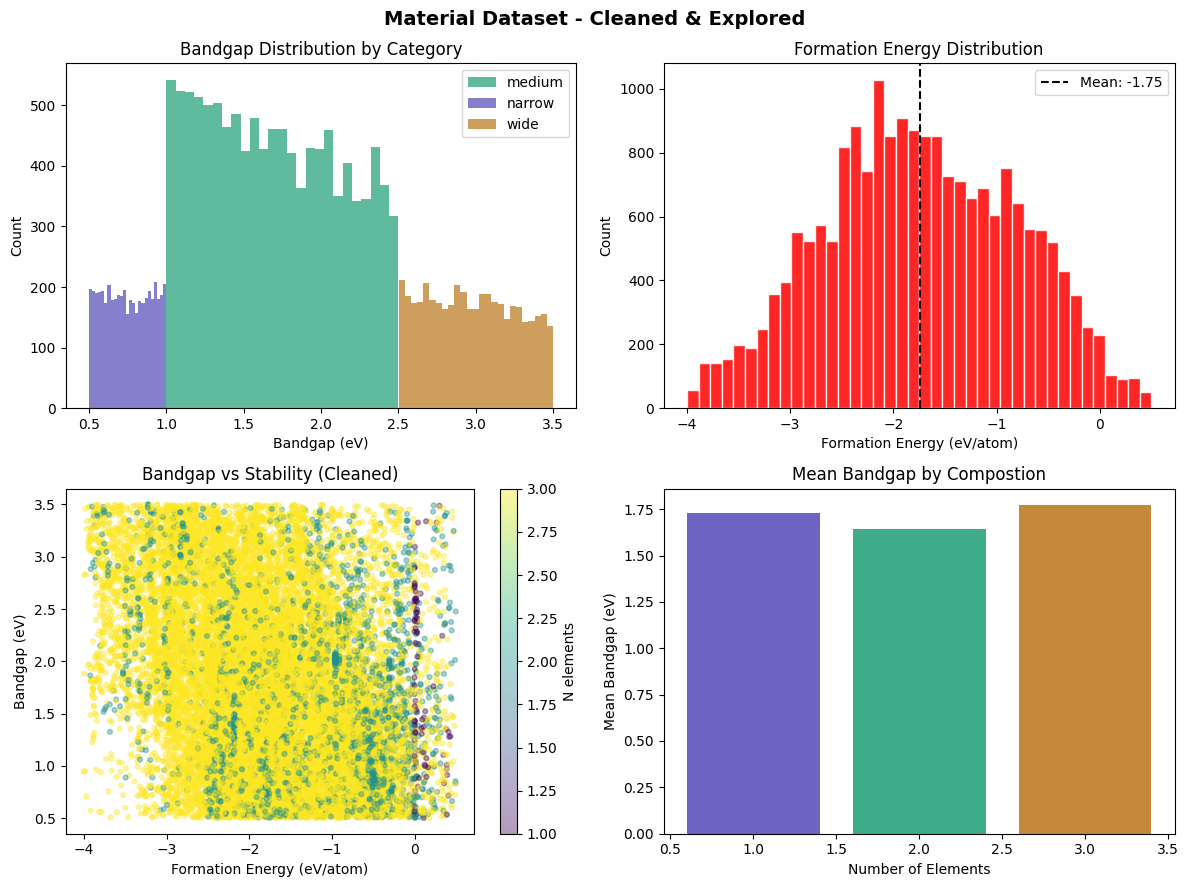

In [24]:
fig,axes=plt.subplots(2,2,figsize=(12,9))
fig.suptitle('Material Dataset - Cleaned & Explored',fontsize=14,fontweight='bold')

#bandgap distribution by category
colors={'narrow':'#524AB7','medium':'#1D9E75','wide':'#BA7517'}
for cat,grp in df_clean.groupby('bg_category'):
    axes[0,0].hist(grp['bandgap'],bins=25,alpha=0.7,label=cat,color=colors[cat])
axes[0,0].set_xlabel('Bandgap (eV)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Bandgap Distribution by Category')
axes[0,0].legend()
    #formation energy distribution 
axes[0,1].hist(df_clean['formation_energy'],bins=40,color='red',edgecolor='white',alpha=0.85)
axes[0,1].axvline(df_clean['formation_energy'].mean(),color='black',linestyle='--',label=f"Mean: {df_clean['formation_energy'].mean():.2f}")
axes[0,1].set_xlabel('Formation Energy (eV/atom)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Formation Energy Distribution')
axes[0,1].legend()

#bandgap vs formation energy(clean)
sc=axes[1,0].scatter(df_clean['formation_energy'],df_clean['bandgap'],c=df_clean['n_elements'],cmap='viridis',alpha=0.4,s=12)
plt.colorbar(sc,ax=axes[1,0],label='N elements')
axes[1,0].set_xlabel('Formation Energy (eV/atom)')
axes[1,0].set_ylabel('Bandgap (eV)')
axes[1,0].set_title('Bandgap vs Stability (Cleaned)')

# mean bandgap per element count
summary=df_clean.groupby('n_elements')['bandgap'].mean()
axes[1,1].bar(summary.index, summary.values,color=['#534AB7','#1D9E75','#BA7517'],alpha=0.85)
axes[1,1].set_xlabel('Number of Elements')
axes[1,1].set_ylabel('Mean Bandgap (eV)')
axes[1,1].set_title('Mean Bandgap by Compostion')
plt.tight_layout()
plt.savefig('day2_clean_exploration.png',dpi=150,bbox_inches='tight')
plt.show()


In [25]:
df_clean.to_csv("materials_clean.csv", index=False)
print(f"Clean dataset saved - {len(df_clean)} materials")
print(f"Columns: {list(df_clean.columns)}")

Clean dataset saved - 19888 materials
Columns: ['id', 'formula', 'bandgap', 'formation_energy', 'density', 'volume', 'n_elements', 'energy_per_volume', 'is_binary', 'is_ternary', 'bg_category']


.In day 2 i learnt how to do filtering , sorting , groupby , some keywords, how to check duplicates and missing values and how to remove those.
.reomved the outliers which hurts the ML models.
.adding some new columns which are helpfull like bandgap category which is very easy to learn
.plotted 4 graphs of the clean data 
